# Quantum Tilted Loss in QAOA and HEA for MaxCut

This notebook explores the performance of the **Quantum Tilted Loss Function** in solving the MaxCut problem using the **Quantum Approximate Optimization Algorithm (QAOA)** and a **Hardware Efficient Ansatz (HEA)**.

### 1. Mathematical Background
The standard loss function in VQA is the expectation value of the Hamiltonian:
$$\mathcal{L}_{std}(\theta) = \bra{\psi(\theta)} H \ket{\psi(\theta)}$$

The **Quantum Tilted Loss Function** is defined as:
$$\mathcal{L}_\gamma(H,\rho(\theta)) := - \frac{1}{\gamma} \log \text{tr} \left( e^{- \gamma H} \rho(\theta) \right)$$
where $\gamma$ is a real parameter. As $\gamma \to 0$, it recovers the standard expectation value. For $\gamma > 0$, it penalizes high-energy (sub-optimal) states more heavily, potentially accelerating convergence to the ground state.

### 2. Goal
1. Compare Standard Loss vs Tilted Loss for MaxCut with QAOA.
2. Test Tilted Loss with Hardware Efficient Ansatz.
3. Compare the algorithm performance with different fixed values of $\gamma$ (0.1, 5, 10, 20, 100).
4. Investigate the effect of tuning $\gamma$ using different schedules (Linear, Sigmoid, Exponential, Logarithmic).

In [1]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import time

# Set random seed for reproducibility
np.random.seed(42)

In [2]:
# Define a small graph for MaxCut (4-node ring)
nodes = 4
edges = [(0, 1), (1, 2), (2, 3), (3, 0)]

# Hamiltonian: H = sum 0.5 * (Zi * Zj - 1) for (i,j) in edges
# Minimizing this minimizes edges with same spin, thus maximizing the cut.
coeffs = [0.5] * len(edges) + [-0.5] * len(edges)
obs = [qml.PauliZ(i) @ qml.PauliZ(j) for i, j in edges] + [qml.Identity(i) for i in range(len(edges))]
H = qml.Hamiltonian(coeffs, obs)

print(f'Hamiltonian for {nodes}-node MaxCut:\n', H)

Hamiltonian for 4-node MaxCut:
 0.5 * (Z(0) @ Z(1)) + 0.5 * (Z(1) @ Z(2)) + 0.5 * (Z(2) @ Z(3)) + 0.5 * (Z(3) @ Z(0)) + -0.5 * I(0) + -0.5 * I(1) + -0.5 * I(2) + -0.5 * I(3)


In [3]:
dev = qml.device('default.qubit', wires=nodes)

# QAOA Ansatz
def qaoa_layer(gamma, beta, edges):
    for i, j in edges:
        qml.IsingZZ(2 * gamma, wires=[i, j])
    for i in range(nodes):
        qml.RX(2 * beta, wires=i)

@qml.qnode(dev)
def qaoa_circuit(params, p=1):
    # Start in superposition
    for i in range(nodes):
        qml.Hadamard(wires=i)
    # p layers of QAOA
    alphas = params[:p]
    betas = params[p:]
    for i in range(p):
        qaoa_layer(alphas[i], betas[i], edges)
    return qml.probs(wires=range(nodes))

# Hardware Efficient Ansatz (HEA)
@qml.qnode(dev)
def hea_circuit(params, layers=2):
    # params shape: (layers, nodes, 2) for RY and RZ
    idx = 0
    for L in range(layers):
        for i in range(nodes):
            qml.RY(params[idx], wires=i); idx += 1
            qml.RZ(params[idx], wires=i); idx += 1
        # Entanglement (ring of CNOTs)
        for i in range(nodes):
            qml.CNOT(wires=[i, (i + 1) % nodes])
    # Final rotation layer
    for i in range(nodes):
        qml.RY(params[idx], wires=i); idx += 1
    return qml.probs(wires=range(nodes))

In [4]:
def get_energies(nodes, edges):
    # Precompute eigenvalues of the MaxCut Hamiltonian for all basis states
    energies = []
    for i in range(2**nodes):
        bitstring = format(i, f'0{nodes}b')
        spins = [1 if b == '0' else -1 for b in bitstring]
        energy = 0
        for u, v in edges:
            energy += 0.5 * (spins[u] * spins[v] - 1)
        energies.append(energy)
    return np.array(energies)

energies = get_energies(nodes, edges)

def standard_loss(probs):
    return np.dot(probs, energies)

def tilted_loss(probs, gamma_val):
    # Avoid gamma = 0 to prevent division by zero; use standard limit
    if abs(gamma_val) < 1e-9:
        return standard_loss(probs)
    # tr(exp(-gamma*H) * rho) = sum(p_i * exp(-gamma * E_i))
    expectation_exp = np.dot(probs, np.exp(-gamma_val * energies))
    return - (1.0 / gamma_val) * np.log(expectation_exp)

## Task 1: QAOA Comparison (Standard vs Tilted)

Optimizing Standard QAOA...
Optimizing Tilted QAOA...


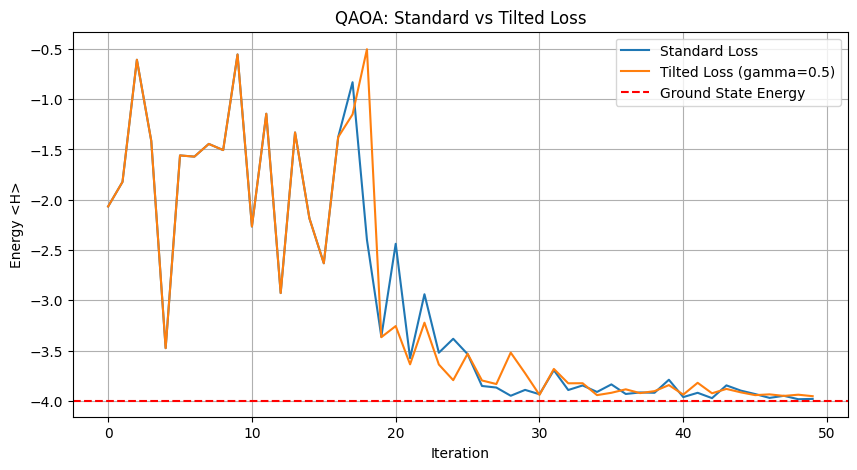

In [5]:
p = 8
init_params = np.random.uniform(0, np.pi, 2 * p, requires_grad=True)
gamma_fixed = 0.5

history_std = []
history_tilted = []

def cost_std(params):
    probs = qaoa_circuit(params, p=p)
    loss = standard_loss(probs)
    history_std.append(loss)
    return loss

def cost_tilted(params):
    probs = qaoa_circuit(params, p=p)
    loss = tilted_loss(probs, gamma_fixed)
    # For comparison, we store the actual energy
    history_tilted.append(standard_loss(probs))
    return loss

print('Optimizing Standard QAOA...')
res_std = minimize(cost_std, init_params, method='COBYLA', options={'maxiter': 50})

print('Optimizing Tilted QAOA...')
res_tilted = minimize(cost_tilted, init_params, method='COBYLA', options={'maxiter': 50})

plt.figure(figsize=(10, 5))
plt.plot(history_std, label='Standard Loss')
plt.plot(history_tilted, label=f'Tilted Loss (gamma={gamma_fixed})')
plt.axhline(y=min(energies), color='r', linestyle='--', label='Ground State Energy')
plt.xlabel('Iteration')
plt.ylabel('Energy <H>')
plt.title('QAOA: Standard vs Tilted Loss')
plt.legend()
plt.grid(True)
plt.show()

## Task 2: HEA with Tilted Loss

Optimizing HEA with Standard Loss...
Optimizing HEA with Tilted Loss...


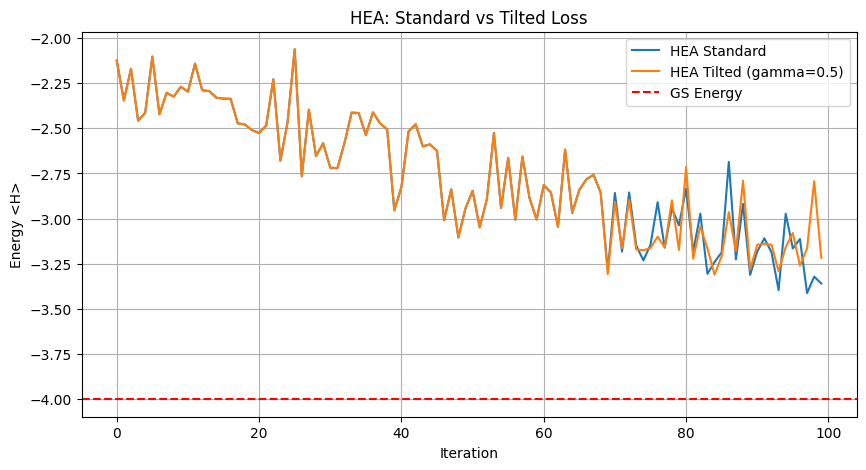

In [6]:
hea_layers = 8
num_params = hea_layers * nodes * 2 + nodes
init_params_hea = np.random.uniform(0, 2 * np.pi, num_params, requires_grad=True)

history_hea_std = []
history_hea_tilted = []

def cost_hea_std(params):
    probs = hea_circuit(params, layers=hea_layers)
    loss = standard_loss(probs)
    history_hea_std.append(loss)
    return loss

def cost_hea_tilted(params):
    probs = hea_circuit(params, layers=hea_layers)
    loss = tilted_loss(probs, gamma_fixed)
    history_hea_tilted.append(standard_loss(probs))
    return loss

print('Optimizing HEA with Standard Loss...')
minimize(cost_hea_std, init_params_hea, method='COBYLA', options={'maxiter': 100})

print('Optimizing HEA with Tilted Loss...')
minimize(cost_hea_tilted, init_params_hea, method='COBYLA', options={'maxiter': 100})

plt.figure(figsize=(10, 5))
plt.plot(history_hea_std, label='HEA Standard')
plt.plot(history_hea_tilted, label=f'HEA Tilted (gamma={gamma_fixed})')
plt.axhline(y=min(energies), color='r', linestyle='--', label='GS Energy')
plt.xlabel('Iteration')
plt.ylabel('Energy <H>')
plt.title('HEA: Standard vs Tilted Loss')
plt.legend()
plt.grid(True)
plt.show()

## Task 3: Effect of Different Fixed Gamma Values

We examine and compare the algorithm performance using different fixed values of $\gamma$: 0.1, 5, 10, 20, 100.

Optimizing Tilted QAOA with gamma=0.1...
Optimizing Tilted QAOA with gamma=20...
Optimizing Tilted QAOA with gamma=200...


e:\李修凡的资料\博三（下）\QTR\code\qi-QTR\venv\Lib\site-packages\pennylane\numpy\tensor.py:156: RuntimeWarning: overflow encountered in exp
  res = super().__array_ufunc__(ufunc, method, *args, **kwargs)


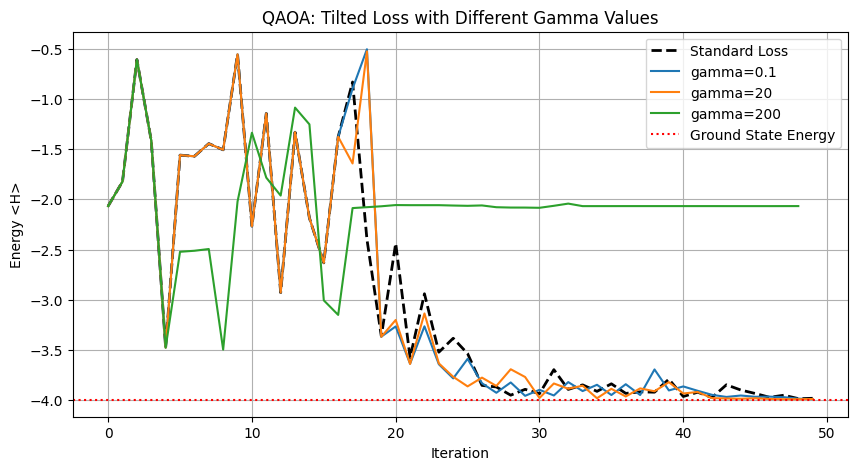

In [7]:
gamma_values = [0.1, 20, 200]
results_gamma = {}

for g in gamma_values:
    print(f'Optimizing Tilted QAOA with gamma={g}...')
    hist = []
    def cost_tilted_g(params):
        probs = qaoa_circuit(params, p=p)
        loss = tilted_loss(probs, g)
        hist.append(standard_loss(probs))
        return loss
    minimize(cost_tilted_g, init_params, method='COBYLA', options={'maxiter': 50})
    results_gamma[g] = hist

plt.figure(figsize=(10, 5))
plt.plot(history_std, label='Standard Loss', linestyle='--', color='black', linewidth=2)
for g in gamma_values:
    plt.plot(results_gamma[g], label=f'gamma={g}')
plt.axhline(y=min(energies), color='r', linestyle=':', label='Ground State Energy')
plt.xlabel('Iteration')
plt.ylabel('Energy <H>')
plt.title('QAOA: Tilted Loss with Different Gamma Values')
plt.legend()
plt.grid(True)
plt.show()


## Task 4: Evaluating Gamma Schedules

We explore how changing $\gamma$ during optimization affects performance.
The schedules tested are:
1. **Linear**: $\gamma(t) = \gamma_0 + (\gamma_f - \gamma_0) \frac{t}{T}$
2. **Sigmoid**: $\gamma(t) = \gamma_0 + \frac{\gamma_f - \gamma_0}{1 + e^{-10 (\frac{t}{T} - 0.5)}}$
3. **Exponential**: $\gamma(t) = \gamma_0 \left( \frac{\gamma_f}{\gamma_0} \right)^{\frac{t}{T}}$
4. **Logarithmic**: $\gamma(t) = \gamma_0 + (\gamma_f - \gamma_0) \frac{\ln(1 + t)}{\ln(1 + T)}$

Testing linear schedule...
Testing sigmoid schedule...
Testing exponential schedule...
Testing logarithmic schedule...


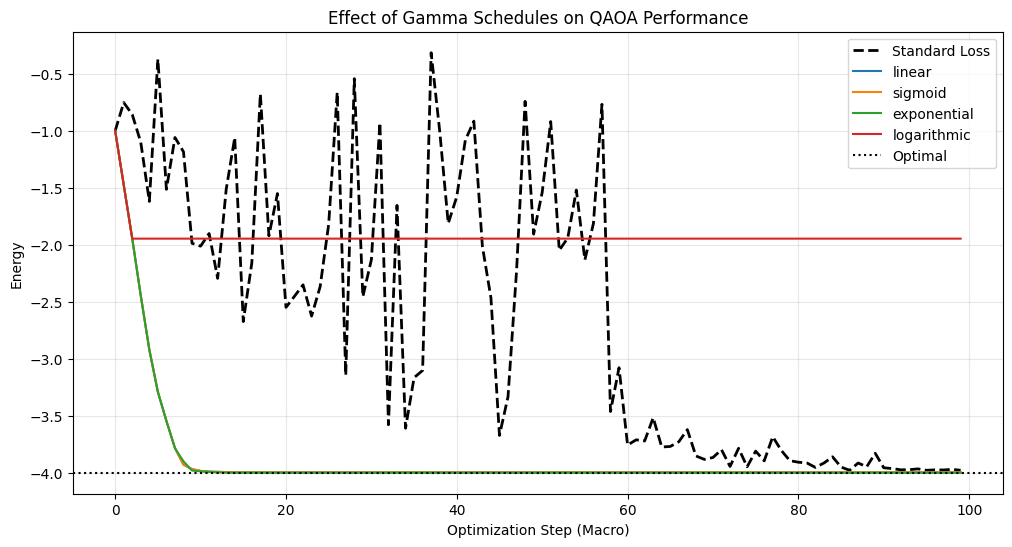

In [8]:
T = 100 # Total macro iterations
gamma_0, gamma_f = 0.01, 1000

def get_gamma_schedule(name, t, T):
    if name == 'linear':
        return gamma_0 + (gamma_f - gamma_0) * (t / T)
    elif name == 'sigmoid':
        return gamma_0 + (gamma_f - gamma_0) / (1 + np.exp(-10 * (t/T - 0.5)))
    elif name == 'exponential':
        return gamma_0 * (gamma_f / gamma_0)**(t / T)
    elif name == 'logarithmic':
        return gamma_0 + (gamma_f - gamma_0) * np.log(1 + t) / np.log(1 + T)
    return gamma_0

schedules = ['linear', 'sigmoid', 'exponential', 'logarithmic']
results_schedules = {}
p = 10
initial_params = np.random.uniform(0, np.pi, 2 * p, requires_grad=True)

for sched in schedules:
    print(f'Testing {sched} schedule...')
    hist = []
    params = initial_params
    
    # Custom optimization loop with dynamic gamma
    for t in range(T):
        current_gamma = get_gamma_schedule(sched, t, T)
        probs = qaoa_circuit(params, p=p)
        hist.append(standard_loss(probs))
        def cost_tilted_g(params):
            probs = qaoa_circuit(params, p=p)
            loss = tilted_loss(probs, current_gamma)
            return loss
        res = minimize(cost_tilted_g, params, method='Nelder-Mead', options={'maxiter': 1})
        params = res.x
    results_schedules[sched] = hist

history_std = []
params = initial_params
def cost_std(params):
    probs = qaoa_circuit(params, p=p)
    loss = standard_loss(probs)
    history_std.append(loss)
    return loss
minimize(cost_std, params, method='COBYLA', options={'maxiter': 100})

plt.figure(figsize=(12, 6))
plt.plot(history_std, label='Standard Loss', linestyle='--', color='black', linewidth=2)
for name, data in results_schedules.items():
    plt.plot(data, label=name)
plt.axhline(y=min(energies), color='black', linestyle=':', label='Optimal')
plt.xlabel('Optimization Step (Macro)')
plt.ylabel('Energy')
plt.title('Effect of Gamma Schedules on QAOA Performance')
plt.legend()
plt.grid(alpha=0.3)
plt.show()